In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
sns.set(style='white', rc={'figure.figsize':(14, 12), 'animation.html': 'html5'})

import colorcet as cc

import os


In [2]:
# Ignore UserWarnings
import warnings
warnings.simplefilter('ignore', UserWarning)

In [3]:
# Function to save each frame as an image
def save_frame(frame, index, df, title=None, cbar=True, color='lp_photoz', df2=None, color2=None):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    if index < num_frames:
        # Plot data and rotate once
        sc = plot_data(ax, df, color)
        if color2!=None:
            plot_data(ax, df2, color2)
        if cbar==True:
            cbar = fig.colorbar(sc)
            if color=='lp_photoz':
                cbar.set_label(r'$z_\mathrm{LePHARE}$', fontsize=25)
                cbar.ax.tick_params(labelsize=20)
            elif color=='Match_specz':
                cbar.set_label(r'$z_\mathrm{spec}$', fontsize=25)
                cbar.ax.tick_params(labelsize=20)
            elif color=='specz':
                cbar.set_label(r'$z_\mathrm{spec}$', fontsize=25)
                cbar.ax.tick_params(labelsize=20)
            elif color=='lp_sSFR_best':
                cbar.set_label(r'sSFR [yr$^{-1}$]', fontsize=25)
                cbar.ax.tick_params(labelsize=20)
        
        rotate_plot(ax, (index * 360 / num_frames)-95)

    if title!=None:
        ax.set_title(title, fontsize=16)
    
    filename = os.path.join(output_dir, f"frame_{index:04d}.png")
    print(f"Saving frame {index} to {filename}")
    plt.savefig(filename, bbox_inches='tight')#, dpi=200)
    plt.close(fig)


def save_frame2(frame, index, df, title=None, cbar=True, color='lp_photoz', df2=None, color2=None):
    fig = plt.figure(figsize=(10,8))#, dpi=200)
    ax = fig.add_subplot(111, projection='3d')
    
    if index < num_frames:
        # Plot data and rotate once
        sc = plot_data3(df, color, cbar=cbar)
        if color2!=None:
            plot_data3(df2, color2, cbar=cbar)
        
        rotate_plot(sc[1], (index * 360 / num_frames)-95)

    if title!=None:
        ax.set_title(title, fontsize=16)
    
    filename = os.path.join(output_dir, f"frame_{index:04d}.png")
    print(f"Saving frame {index} to {filename}")
    plt.margins(y=0)
    plt.savefig(filename, bbox_inches='tight')#, pad_inches=0)#, dpi=200)
    plt.close('all')



# Function to plot data
def plot_data(ax, df, color='lp_photoz'):

    if color == 'lp_photoz':
        sc = ax.scatter(df['X1'], df['Z1'], df['Y1'], c=df[color], s=1., alpha=0.7, cmap=get_cmap('cet_CET_R1'), vmin=0, vmax=5)
    elif color == 'Match_specz':
        sc = ax.scatter(df['X1'], df['Z1'], df['Y1'], c=df[color], s=1, alpha=0.7, cmap=get_cmap('cet_CET_R1'), vmin=0, vmax=5)
    elif color == 'specz':
        sc = ax.scatter(df['X1'], df['Z1'], df['Y1'], c=df[color], s=1, alpha=0.7, cmap=get_cmap('cet_CET_R1'), vmin=0, vmax=5)
    elif color == 'lp_sSFR_best':
        sc = ax.scatter(df['X1'], df['Z1'], df['Y1'], c=df[color], s=1., alpha=0.7, cmap=get_cmap('cet_CET_D1A_r'), vmin=-12, vmax=-8)
    elif color=='black':
        sc = ax.scatter(df['X1'], df['Z1'], df['Y1'], c='k', s=7, alpha=1.)
    else:
        sc = ax.scatter(df['X1'], df['Z1'], df['Y1'], c=df[color], s=1, alpha=0.7, cmap=get_cmap('cet_CET_R1'))
    
    return sc


# Function to plot data
def plot_data2(df, color='lp_photoz', cbar=True):

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    if color == 'lp_photoz':
        sc = ax.scatter(df['Z1'], df['X1'], -df['Y1'], c=df[color], s=1., alpha=0.7, cmap=get_cmap('cet_CET_R1'), vmin=0, vmax=5)
    elif color == 'Match_specz':
        sc = ax.scatter(df['Z1'], df['X1'], -df['Y1'], c=df[color], s=1, alpha=0.7, cmap=get_cmap('cet_CET_R1'), vmin=0, vmax=5)
    elif color == 'specz':
        sc = ax.scatter(df['Z1'], df['X1'], -df['Y1'], c=df[color], s=1, alpha=0.7, cmap=get_cmap('cet_CET_R1'), vmin=0, vmax=5)
    elif color == 'lp_sSFR_best':
        sc = ax.scatter(df['Z1'], df['X1'], -df['Y1'], c=df[color], s=1., alpha=0.7, cmap=get_cmap('cet_CET_D1A_r'), vmin=-12, vmax=-8)
    elif color=='black':
        sc = ax.scatter(df['Z1'], df['X1'], -df['Y1'], c='k', s=7, alpha=1.)
    else:
        sc = ax.scatter(df['Z1'], df['X1'], -df['Y1'], c=df[color], s=1, alpha=0.7, cmap=get_cmap('cet_CET_R1'))

    if cbar==True:
        cbar = fig.colorbar(sc)
    if color=='lp_photoz':
        cbar.set_label(r'$z_\mathrm{LePHARE}$', fontsize=25)
        cbar.ax.tick_params(labelsize=20)
    elif color=='Match_specz':
        cbar.set_label(r'$z_\mathrm{spec}$', fontsize=25)
        cbar.ax.tick_params(labelsize=20)
    elif color=='specz':
        cbar.set_label(r'$z_\mathrm{spec}$', fontsize=25)
        cbar.ax.tick_params(labelsize=20)
    elif color=='lp_sSFR_best':
        cbar.set_label(r'sSFR [yr$^{-1}$]', fontsize=25)
        cbar.ax.tick_params(labelsize=20)

    
    return sc


# Function to plot data
def plot_data3(df, color='lp_photoz', cbar=True):

    fig = plt.figure(figsize=(10, 8), dpi=100)  # Increase overall figure size
    #ax = fig.add_subplot(111, projection='3d')
    ax = fig.add_axes([0.0, 0.0, 0.95, 1.0], projection='3d') 
    fig.subplots_adjust(bottom=0, top=1)
    ax.axes.xaxis.set_ticklabels([])
    ax.axes.yaxis.set_ticklabels([])
    ax.axes.zaxis.set_ticklabels([])
    #plt.tight_layout(pad=0)
    plt.margins(y=0)



    # Create scatter plot
    if color == 'lp_photoz':
        sc = ax.scatter(df['Z1'], df['X1'], -df['Y1'], c=df[color], s=1., alpha=0.7, cmap=get_cmap('cet_CET_R1'), vmin=0, vmax=5)
    elif color == 'Match_specz':
        sc = ax.scatter(df['Z1'], df['X1'], -df['Y1'], c=df[color], s=1, alpha=0.7, cmap=get_cmap('cet_CET_R1'), vmin=0, vmax=5)
    elif color == 'specz':
        sc = ax.scatter(df['Z1'], df['X1'], -df['Y1'], c=df[color], s=1, alpha=0.7, cmap=get_cmap('cet_CET_R1'), vmin=0, vmax=5)
    elif color == 'lp_sSFR_best':
        sc = ax.scatter(df['Z1'], df['X1'], -df['Y1'], c=df[color], s=1., alpha=0.7, cmap=get_cmap('cet_CET_D1A_r'), vmin=-12, vmax=-8)
    elif color == 'black':
        sc = ax.scatter(df['Z1'], df['X1'], -df['Y1'], c='k', s=7, alpha=1.)
    else:
        sc = ax.scatter(df['Z1'], df['X1'], -df['Y1'], c=df[color], s=1, alpha=0.7, cmap=get_cmap('cet_CET_R1'))

    # Add colorbar with manual size control
    if cbar:
        # Custom position: [left, bottom, width, height]
        cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])  # Narrow and tall colorbar
        cbar = fig.colorbar(sc, cax=cbar_ax)

        # Label settings
        if color == 'lp_photoz':
            cbar.set_label(r'$z_\mathrm{LePHARE}$', fontsize=25)
        elif color == 'Match_specz':
            cbar.set_label(r'$z_\mathrm{spec}$', fontsize=25)
        elif color == 'specz':
            cbar.set_label(r'$z_\mathrm{spec}$', fontsize=25)
        elif color == 'lp_sSFR_best':
            cbar.set_label(r'sSFR [yr$^{-1}$]', fontsize=25)

        cbar.ax.tick_params(labelsize=20)
        

    return fig, ax



# Function to rotate plot
def rotate_plot(ax, angle):
    ax.view_init(elev=10, azim=angle)


In [4]:
#df = pd.read_parquet('df_118k_maps.parquet')
#df

In [5]:
df0 = pd.read_parquet('df7_maps_250819.parquet')
df = pd.read_parquet('spec95_ugrizyJH_maps_250819.parquet')
#df = pd.read_parquet('agn_umap7.parquet')
df

,ID,RA,DEC,FLAG_COMBINED,CFHT_u_FLUX,CFHT_u_FLUXERR,CFHT_u_MAGERR,HSC_g_FLUX,HSC_g_FLUXERR,HSC_g_MAGERR,HSC_r_FLUX,HSC_r_FLUXERR,HSC_r_MAGERR,HSC_i_FLUX,HSC_i_FLUXERR,HSC_i_MAGERR,HSC_z_FLUX,HSC_z_FLUXERR,HSC_z_MAGERR,HSC_y_FLUX,HSC_y_FLUXERR,HSC_y_MAGERR,UVISTA_J_FLUX,UVISTA_J_FLUXERR,UVISTA_J_MAGERR,UVISTA_H_FLUX,UVISTA_H_FLUXERR,UVISTA_H_MAGERR,UVISTA_Ks_FLUX,UVISTA_Ks_FLUXERR,UVISTA_Ks_MAGERR,IRAC_CH1_FLUX,IRAC_CH1_FLUXERR,IRAC_CH1_MAGERR,IRAC_CH2_FLUX,IRAC_CH2_FLUXERR,IRAC_CH2_MAGERR,lp_photoz,lp_type,lp_zp_2,lp_NbFilt,lp_zq,lp_model,lp_age,lp_dust,lp_Attenuation,lp_MNUV,lp_MR,lp_MJ,lp_mass_med,lp_mass_med_min68,lp_mass_med_max68,lp_mass_best,lp_SFR_med,lp_sSFR_best,CFHT_u_MAG,HSC_g_MAG,HSC_r_MAG,HSC_i_MAG,HSC_z_MAG,HSC_y_MAG,UVISTA_J_MAG,UVISTA_H_MAG,UVISTA_Ks_MAG,IRAC_CH1_MAG,IRAC_CH2_MAG,u-g,g-r,r-i,i-z,z-y,y-J,J-H,nearest_cat1_ID,nearest_cat1_sep,Id_specz,Id_original,ra_original,dec_original,ra_corrected,dec_corrected,Priority,specz,flag,Confidence_level,survey,compilation_year,public_or_private,Id_COS20_Classic,ra_COS20_Classic,dec_COS20_Classic,Id_COS20_Farmer,ra_COS20_Farmer,dec_COS20_Farmer,Id_COSMOS15,ra_COSMOS15,dec_COSMOS15,Id_COSMOS09,ra_COSMOS09,dec_COSMOS09,photoz,photoz_type,UMAP3D-1,UMAP3D-2,UMAP3D-3,SOM-1,SOM-2
0,535,150.726526,1.795723,0,3.135322,0.004911,0.001979,3.543392,0.005600,0.001707,4.149280,0.006839,0.001707,5.531073,0.006686,0.001311,9.094858,0.011055,0.001310,6.137582,0.023292,0.003891,8.654985,0.055195,0.006917,8.847195,0.061729,0.007971,10.089081,0.037653,0.004077,12.819075,0.017958,0.001854,8.697933,0.024042,0.003679,0.8165,0,NaN,28,1.85,8,1.609000e+08,0.2,1,-20.28363,-21.12927,-21.52369,9.31240,9.27122,9.34644,9.33645,1.23468,-8.087,22.659295,22.526452,22.355068,22.042977,21.503010,21.930007,21.556834,21.532986,21.390371,21.130358,21.551460,0.132843,0.171384,0.312092,0.539966,-0.426997,0.373173,0.023848,57552,0.032255,57552,b'3962782953',150.72652,1.79573,150.72652,1.79573,1,0.82589,4,97,29,2023,1,393505,150.726503,1.795736,535,150.726526,1.795723,334248,150.726575,1.795797,495080,150.72654,1.795808,0.7747,0,-1.975816,1.218150,0.035435,11,32
1,670,149.730259,1.959835,0,1.941518,0.005379,0.003476,1.863746,0.004178,0.002408,2.359093,0.005581,0.002440,3.347864,0.005832,0.001883,4.712861,0.009339,0.002130,5.044670,0.019908,0.004038,5.936375,0.013675,0.002495,7.337306,0.017588,0.002736,9.483263,0.026426,0.003042,13.707825,0.014322,0.001382,12.806878,0.012845,0.001335,1.1792,0,NaN,30,1.02,10,2.273000e+08,0.3,0,-20.49749,-21.89549,-22.47231,9.79095,9.75692,9.83047,9.80739,1.80017,-7.953,23.179647,23.224033,22.968137,22.588081,22.216789,22.142918,21.966197,21.736158,21.457606,21.057579,21.131392,-0.044386,0.255896,0.380057,0.371292,0.073870,0.176721,0.230038,54582,0.166286,54582,b'3962783555',149.73022,1.95986,149.73022,1.95986,1,1.16549,4,97,29,2023,1,562463,149.730243,1.959851,670,149.730259,1.959835,437916,149.730268,1.959866,816008,149.73022,1.959921,1.1465,0,-0.919792,-0.326218,5.726158,30,13
2,692,149.642181,2.379960,0,1.315313,0.006756,0.006467,4.484449,0.005892,0.001415,13.213070,0.007819,0.000612,24.048380,0.008534,0.000384,35.020987,0.013526,0.000416,40.134805,0.026583,0.000678,66.579523,0.061359,0.000999,98.679499,0.078428,0.000908,133.665136,0.058089,0.000475,81.719072,0.032358,0.000524,83.615927,0.028347,0.000451,0.3269,0,NaN,29,0.29,9,5.000000e+09,0.4,1,-16.72223,-20.57175,-21.94677,10.35539,10.31772,10.39305,10.38281,0.19029,-10.190,23.602427,22.270727,21.097491,20.447285,20.039179,19.891197,19.341648,18.914433,18.584955,19.119191,19.094277,1.331700,1.173237,0.650205,0.408106,0.147982,0.549549,0.427216,134345,0.069986,134345,b'174323',149.64220,2.37996,149.64217,2.37995,1,0.30572,4,97,105,2018,1,1020227,149.642181,2.379958,692,149.642181,2.379960,715344,149.642185,2.379964,1306281,149.64216,2.379982,0.3098,0,6.842029,6.652438,3.014578,36,35
3,1143,150.589033,1.889879,0,0.063290,0.003653,0.072636,0.254108,0.004009,0.016990,1.155916,0.005216,0.004662,4.069362,0.005549,0.001476,6.65053

In [6]:
df1_ = df.rename(columns={'UMAP3D-1':'X1', 'UMAP3D-2':'Y1', 'UMAP3D-3':'Z1'})
df0_ = df0.rename(columns={'UMAP3D-1':'X1', 'UMAP3D-2':'Y1', 'UMAP3D-3':'Z1'})

#df1_ = df.rename(columns={'UMAP3D_2-1':'X1', 'UMAP3D_2-2':'Y1', 'UMAP3D_2-3':'Z1'})[['X1', 'Y1', 'Z1']]

In [ ]:
df1_

/var/folders/zr/5945lkps2z573rnydx977g7m0000gn/T/ipykernel_21385/3971651342.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  sc = ax.scatter(df['X1'], df['Z1'], df['Y1'], c=df[color], s=1., alpha=0.9, cmap=get_cmap('cet_CET_R1'), vmin=0, vmax=5)


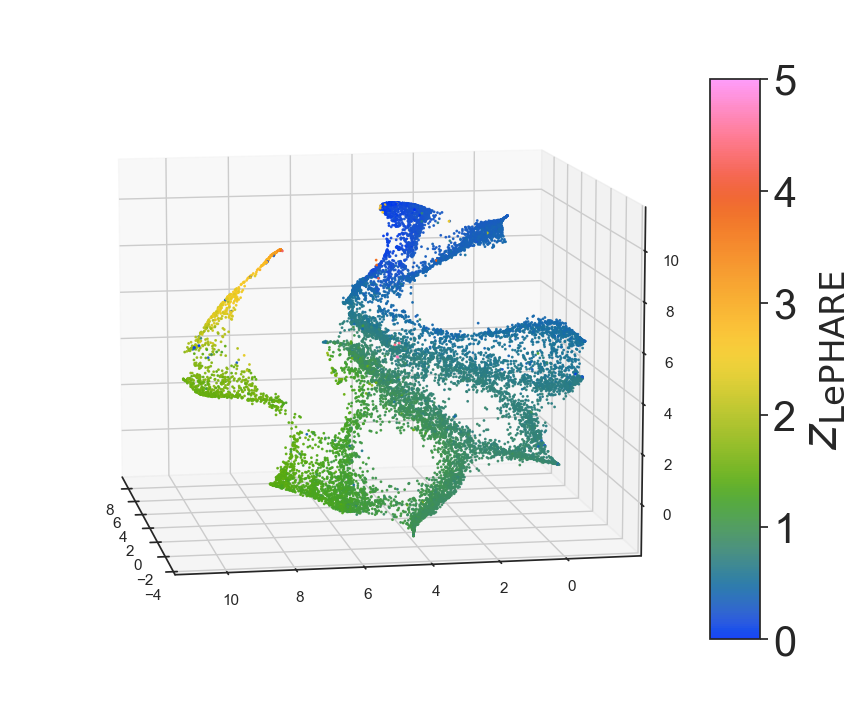

In [ ]:
#df = df0_.copy()
df = df1_.copy()
color = 'lp_photoz'
cbar=True

fig = plt.figure(figsize=(10, 8))  # Increase overall figure size
#ax = fig.add_subplot(111, projection='3d')
ax = fig.add_axes([0.05, 0.05, 0.7, 0.9], projection='3d') 

# Create scatter plot
if color == 'lp_photoz':
    sc = ax.scatter(df['X1'], df['Z1'], df['Y1'], c=df[color], s=1., alpha=0.9, cmap=get_cmap('cet_CET_R1'), vmin=0, vmax=5)
elif color == 'Match_specz':
    sc = ax.scatter(df['X1'], df['Z1'], df['Y1'], c=df[color], s=1, alpha=1., cmap=get_cmap('cet_CET_R1'), vmin=0, vmax=5)
elif color == 'specz':
    sc = ax.scatter(df['Z1'], df['X1'], -df['Y1'], c=df[color], s=1, alpha=0.9, cmap=get_cmap('cet_CET_R1'), vmin=0, vmax=5)

elif color == 'lp_sSFR_best':
    sc = ax.scatter(df['X1'], df['Z1'], df['Y1'], c=df[color], s=1., alpha=0.9, cmap=get_cmap('cet_CET_D1A_r'), vmin=-12, vmax=-8)
elif color == 'black':
    sc = ax.scatter(df['X1'], df['Z1'], df['Y1'], c='k', s=7, alpha=1.)
else:
    sc = ax.scatter(df['X1'], df['Z1'], df['Y1'], c=df[color], s=1, alpha=1., cmap=get_cmap('cet_CET_R1'))

# Add colorbar with manual size control
if cbar:
    # Custom position: [left, bottom, width, height]
    cbar_ax = fig.add_axes([0.75, 0.15, 0.05, 0.7])  # Narrow and tall colorbar
    cbar = fig.colorbar(sc, cax=cbar_ax)

    # Label settings
    if color == 'lp_photoz':
        cbar.set_label(r'$z_\mathrm{LePHARE}$', fontsize=35)
    elif color == 'Match_specz':
        cbar.set_label(r'$z_\mathrm{spec}$', fontsize=35)
    elif color == 'specz':
        cbar.set_label(r'$z_\mathrm{spec}$', fontsize=35)
    elif color == 'lp_sSFR_best':
        cbar.set_label(r'sSFR [yr$^{-1}$]', fontsize=35)

    cbar.ax.tick_params(labelsize=30)
    ax.view_init(elev=10, azim=170)
    #plt.savefig('cbar_zphot_250829.png')

In [ ]:
df = df0_.copy()
color = 'lp_photoz'
cbar=True

fig = plt.figure(figsize=(10, 8))  # Increase overall figure size
#ax = fig.add_subplot(111, projection='3d')
ax = fig.add_axes([0.05, 0.05, 0.9, 0.95], projection='3d') 

# Create scatter plot
if color == 'lp_photoz':
    sc = ax.scatter(df['X1'], df['Z1'], df['Y1'], c=df[color], s=1., alpha=0.7, cmap=get_cmap('cet_CET_R1'), vmin=0, vmax=5)
elif color == 'Match_specz':
    sc = ax.scatter(df['X1'], df['Z1'], df['Y1'], c=df[color], s=1, alpha=0.7, cmap=get_cmap('cet_CET_R1'), vmin=0, vmax=5)
elif color == 'specz':
    sc = ax.scatter(df['X1'], df['Z1'], df['Y1'], c=df[color], s=1, alpha=0.7, cmap=get_cmap('cet_CET_R1'), vmin=0, vmax=5)
elif color == 'lp_sSFR_best':
    sc = ax.scatter(df['X1'], df['Z1'], df['Y1'], c=df[color], s=1., alpha=0.7, cmap=get_cmap('cet_CET_D1A_r'), vmin=-12, vmax=-8)
elif color == 'black':
    sc = ax.scatter(df['X1'], df['Z1'], df['Y1'], c='k', s=7, alpha=1.)
else:
    sc = ax.scatter(df['X1'], df['Z1'], df['Y1'], c=df[color], s=1, alpha=0.7, cmap=get_cmap('cet_CET_R1'))

# Add colorbar with manual size control
if cbar:
    # Custom position: [left, bottom, width, height]
    cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])  # Narrow and tall colorbar
    cbar = fig.colorbar(sc, cax=cbar_ax)

    # Label settings
    if color == 'lp_photoz':
        cbar.set_label(r'$z_\mathrm{LePHARE}$', fontsize=25)
    elif color == 'Match_specz':
        cbar.set_label(r'$z_\mathrm{spec}$', fontsize=25)
    elif color == 'specz':
        cbar.set_label(r'$z_\mathrm{spec}$', fontsize=25)
    elif color == 'lp_sSFR_best':
        cbar.set_label(r'sSFR [yr$^{-1}$]', fontsize=25)

    cbar.ax.tick_params(labelsize=20)
    ax.view_init(elev=10, azim=170)

In [ ]:
#fig = plt.figure()
#ax = fig.add_subplot(111, projection='3d')
#ax.set_xlim(-2, 11)
#ax.set_ylim(-2, 11)
#ax.set_zlim(-2, 11)
#ax.view_init(elev=10, azim=165)
plot_data3(df=df0_, color='lp_sSFR_best', cbar=True)
#ax.view_init(elev=10, azim=155)
#plot_data(ax, df=df1_, color='black')
#plt.savefig('seed_test_1.png')


In [49]:
# Directory to save the frames
output_dir = os.path.expanduser("~/Desktop/NEWMANGROUP/zphot_250827")
os.makedirs(output_dir, exist_ok=True)

In [ ]:
num_frames = 200

for i in range(num_frames):
    #save_frame(None, i, df=df0_, title=None, cbar=True, color='lp_photoz')#, df2=df1_, color2='black')
    save_frame2(None, i, df=df0_, title=None, cbar=True, color='lp_photoz')#, df2=df1_, color2='black')

In [51]:
output_dir = os.path.expanduser("~/Desktop/NEWMANGROUP/ssfr_250827")
os.makedirs(output_dir, exist_ok=True)

In [ ]:
num_frames = 200
print('hi')

for i in range(num_frames):
    #save_frame(None, i, df=df0_, title=None, cbar=True, color='lp_photoz')#, df2=df1_, color2='black')
    save_frame2(None, i, df=df0_, title=None, cbar=True, color='lp_sSFR_best')#, df2=df1_, color2='black')

In [53]:
df = pd.read_parquet('spec95_ugrizyJH_maps_250819.parquet')
df_ = df.rename(columns={'UMAP3D-1':'X1', 'UMAP3D-2':'Y1', 'UMAP3D-3':'Z1'})

In [54]:
output_dir = os.path.expanduser("~/Desktop/NEWMANGROUP/zspec_250827")
os.makedirs(output_dir, exist_ok=True)

In [ ]:
num_frames = 200
print('hi')

for i in range(num_frames):
    #save_frame(None, i, df=df0_, title=None, cbar=True, color='lp_photoz')#, df2=df1_, color2='black')
    save_frame2(None, i, df=df_, title=None, cbar=True, color='specz')#, df2=df1_, color2='black')

In [56]:
output_dir = os.path.expanduser("~/Desktop/NEWMANGROUP/ssfr_spec_250827")
os.makedirs(output_dir, exist_ok=True)

In [ ]:
num_frames = 200
print('hi')

for i in range(num_frames):
    #save_frame(None, i, df=df0_, title=None, cbar=True, color='lp_photoz')#, df2=df1_, color2='black')
    save_frame2(None, i, df=df_, title=None, cbar=True, color='lp_sSFR_best')#, df2=df1_, color2='black')

can use: 

mkdir -p cropped && for img in *.png; do ffmpeg -i "$img" -vf "crop=in_w:in_h-100:0:50" "cropped/$img"; done

to crop the images

In [ ]:
num_frames = 200
cbar = True
color = 'specz'
save_frame(None, 105, title=None, cbar=cbar, color=color)
#save_frame(None, 115, title=None, cbar=cbar, color=color)
#save_frame(None, 125, title=None, cbar=cbar, color=color)
#save_frame(None, 135, title=None, cbar=cbar, color=color)
#save_frame(None, 145, title=None, cbar=cbar, color=color)

In [10]:
# CONVERT BELOW CODE TO BE RUN DIRECTLY IN ORDER, NO INTERPRETATION

create directory for combined side-by-side images:

mkdir -p twopanel_phot

combine images from two directories and place them in the new one:

ffmpeg -i z_phot/frame_%04d.png -i ssfr_phot/frame_%04d.png -filter_complex "[0][1]hstack=inputs=2" twopanel_phot/frame_%04d.png

mkdir -p twopanel_spec

combine images from two directories and place them in the new one:

ffmpeg -i z_spec/frame_%04d.png -i ssfr_spec/frame_%04d.png -filter_complex "[0][1]hstack=inputs=2" twopanel_spec/frame_%04d.png

mkdir -p fourpanel

ffmpeg -i twopanel_phot/frame_%04d.png -i twopanel_spec/frame_%04d.png -filter_complex "[0][1]vstack=inputs=2" fourpanel/frame_%04d.png

change to new directory:

cd fourpanel

create mp4 video of animation:

ffmpeg -framerate 15 -i frame_%04d.png -vf "scale=iw-mod(iw\,2):ih-mod(ih\,2)" -c:v libx264 -pix_fmt yuv420p fourpanel_animation.mp4

convert to gif:

ffmpeg -i animation.mp4 animation.gif

change gif to half speed:

ffmpeg -i animation.gif -filter_complex "setpts=2*PTS" slowgif.gif

### generic version with nonspecific directory names

create directory for combined side-by-side images:

mkdir -p new_directory

combine images from two directories and place them in the new one:

ffmpeg -i directory_1/frame_%04d.png -i directory_2/frame_%04d.png -filter_complex "[0][1]hstack=inputs=2" new_directory/frame_%04d.png

mkdir -p fourpanel_250828

ffmpeg -i zphot_ssfr_250828/frame_%04d.png -i zspec_ssfr_250828/frame_%04d.png -filter_complex "[0][1]vstack=inputs=2" fourpanel_250828/frame_%04d.png

change to new directory:

cd new_directory

create mp4 video of animation:

ffmpeg -framerate 15 -i frame_%04d.png -vf "scale=iw-mod(iw\,2):ih-mod(ih\,2)" -c:v libx264 -pix_fmt yuv420p animation.mp4

convert to gif:

ffmpeg -i animation.mp4 animation.gif

change gif to half speed:

ffmpeg -i animation.gif -filter_complex "setpts=2*PTS" slowgif.gif

### change names here easily then paste lines into Terminal

create directory for combined side-by-side images:

mkdir -p zspec_ssfr_250828

combine images from two directories and place them in the new one:

ffmpeg -i cropped_zspec_250828/frame_%04d.png -i cropped_ssfr_spec_250828/frame_%04d.png -filter_complex "[0][1]hstack=inputs=2" zspec_ssfr_250828/frame_%04d.png

change to new directory:

cd zphot_ssfr_250826

create mp4 video of animation:

ffmpeg -framerate 15 -i frame_%04d.png -vf "scale=iw-mod(iw\,2):ih-mod(ih\,2)" -c:v libx264 -pix_fmt yuv420p animation.mp4

convert to gif:

ffmpeg -i animation.mp4 animation.gif

change gif to half speed:

ffmpeg -i animation.gif -filter_complex "setpts=2*PTS" slowgif.gif

### vertically stack (can be used to make two 2-panels into one 4-panel):

mkdir -p fourpanel_250828

ffmpeg -i zphot_ssfr_250828/frame_%04d.png -i zspec_ssfr_250828/frame_%04d.png -filter_complex "[0][1]vstack=inputs=2" fourpanel_250828/frame_%04d.png



### crop

can use: 

mkdir -p cropped_ssfr_spec_250828 && for img in ssfr_spec_250827/*.png; do ffmpeg -i "$img" -vf "crop=in_w:in_h-100:0:50" "cropped_ssfr_spec_250828/$(basename "$img")"; done

to crop the images

the crop size is specified like: crop=in_w:in_h-<total_crop>:0:<top_crop>

takes off leftmost and rightmost pixels in addition to 50 top and bottom

mkdir -p cropped_zspec_250828 && for img in zspec_250827/*.png; do ffmpeg -i "$img" -vf "crop=iw-2:ih-100:1:50" "cropped_zspec_250828/$(basename "$img")"; done

mkdir -p cropped_test && for img in *.png; do ffmpeg -i "$img" -vf "crop=in_w-2:in_h:2:0" "cropped_test/$img"; done

crop one pixel off left and right: for img in *.png; do ffmpeg -i "$img" -vf "crop=iw-2:ih:1:0" "cropped/$img"; done